## Downloading and loading the dataset

In [3]:
import kagglehub
import os

download_path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

local_path = "/content/garbage_data"

if not os.path.exists(local_path):
    os.symlink(download_path, local_path)
    print(f"Success! Dataset linked to: {local_path}")
else:
    print(f"Note: {local_path} already exists.")

print("Files found:", os.listdir(local_path)[:5], "...")

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
Success! Dataset linked to: /content/garbage_data
Files found: ['standardized_384', 'original', 'standardized_256'] ...


In [4]:
import random
import torch
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

In [5]:
data_dir = "/content/garbage_data/original"

## Part A: Designing and Analyzing Convolutional Neural Networks from Scratch

### Data Understanding, Analysis, Visualization and Cleaning

In [6]:
# Loading the dataset as a torch dataset object using ImageFolder, as it is already in the standard ImageFolder needed format
# Original -> class1, class2
base_dataset = datasets.ImageFolder(root=data_dir)

class_names = base_dataset.classes
num_classes = len(class_names)

print("Total images:", len(base_dataset))
print("Classes:", class_names)

Total images: 12259
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [7]:
# Count occurrences
counts = Counter(base_dataset.targets)
values = [counts[i] for i in range(len(class_names))]

# Print the text counts
for name, count in zip(class_names, values):
    print(f"{name}: {count}")

battery: 756
biological: 699
cardboard: 1411
clothes: 1892
glass: 1736
metal: 930
paper: 1336
plastic: 1597
shoes: 1449
trash: 453


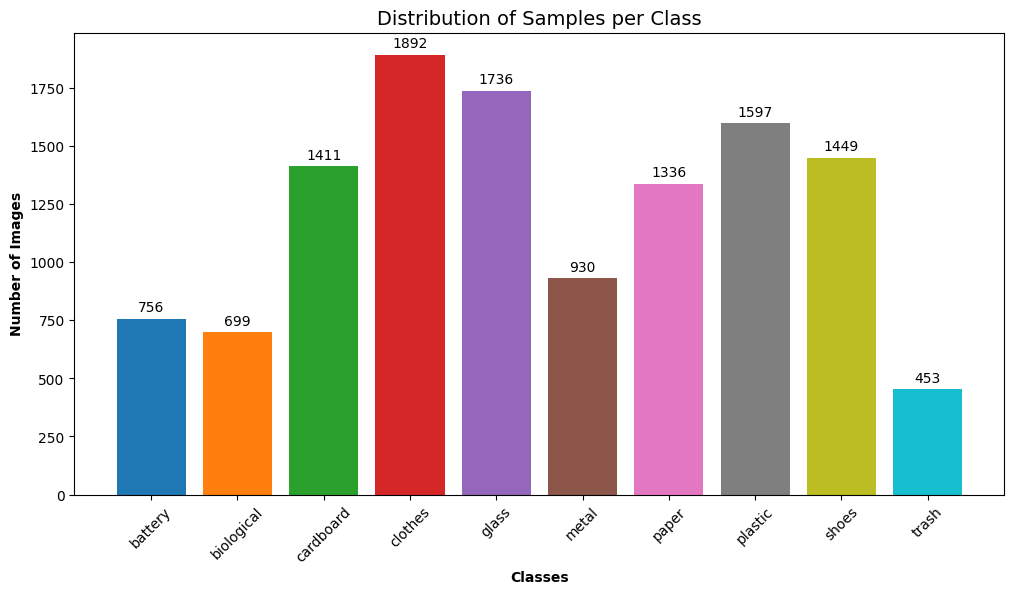

In [8]:
# Plotting
plt.figure(figsize=(12, 6))

# Assign 'tab10' colormap for 10 different colors
bars = plt.bar(class_names, values, color=plt.cm.tab10.colors)

# Add the counts above the bars
plt.bar_label(bars, padding=3)

# Formatting
plt.xlabel('Classes', fontweight='bold')
plt.ylabel('Number of Images', fontweight='bold')
plt.title('Distribution of Samples per Class', fontsize=14)
plt.xticks(rotation=45) # Rotates names if they overlap
plt.show()

In [9]:
train_transform = v2.Compose([
  v2.ToImage(), # Convert to tensor format
  v2.Resize((224, 224)), # Resize to standard size
  v2.RandomHorizontalFlip(p=0.5), # Random flip to vary data
  v2.RandomRotation(degrees=10), # Random tilt to vary data
  v2.ToDtype(torch.float32, scale=True), # Convert to float and scale 0-1
  v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Standardize using ImageNet statistics
])

eval_transform = v2.Compose([
  v2.ToImage(), # Convert to tensor format
  v2.Resize((224, 224)), # Resize to standard size
  v2.ToDtype(torch.float32, scale=True), # Convert to float and scale 0-1
  v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Standardize using ImageNet statistics
])

In [10]:
# Create two bases so we can apply different transforms to the same images (as eval wont need augmentation)
train_base = datasets.ImageFolder(data_dir, transform=train_transform)
eval_base = datasets.ImageFolder(data_dir, transform=eval_transform)

In [11]:
# Get indices and labels for stratified splitting
indices = list(range(len(train_base)))
labels = train_base.targets

# Split: 70% Train, 30% Temp (Val + Test)
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=labels, random_state=42
)

# Split Temp: 15% Val, 15% Test
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=42
)

train_ds = Subset(train_base, train_idx)
val_ds = Subset(eval_base, val_idx)
test_ds = Subset(eval_base, test_idx)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}"

'Train: 8581, Val: 1839, Test: 1839'

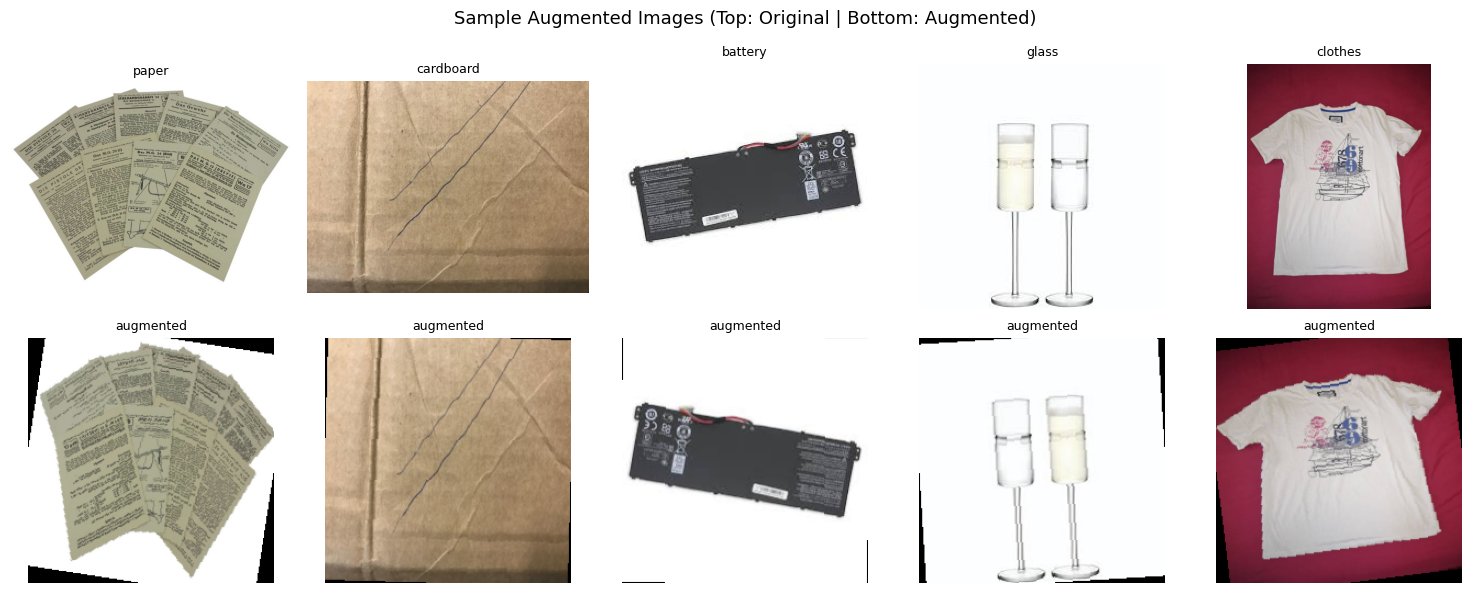

In [12]:
raw_base = datasets.ImageFolder(data_dir)  # no transform, for display

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Augmented Images (Top: Original | Bottom: Augmented)", fontsize=13)

sample_indices = random.sample(range(len(raw_base)), 5)

for col, idx in enumerate(sample_indices):
  raw_img, label = raw_base[idx]

  # Top row: original PIL image
  axes[0, col].imshow(raw_img)
  axes[0, col].set_title(class_names[label], fontsize=9)
  axes[0, col].axis("off")

  # Bottom row: apply train_transform (undo normalize for display)
  aug_tensor, _ = train_base[idx]
  # Denormalize
  mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
  std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
  aug_img = (aug_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

  axes[1, col].imshow(aug_img)
  axes[1, col].set_title("augmented", fontsize=9)
  axes[1, col].axis("off")

plt.tight_layout()
plt.show()

### Design, Train, and Evaluate a Baseline Model

**Model Architecture**

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
class BaselineCNN(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(2, 2)
    self.fc1 = nn.Linear(128 * 28 * 28, 512)
    self.fc2 = nn.Linear(512, 128)
    self.fc3 = nn.Linear(128, num_classes)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = self.pool(F.relu(self.conv3(x)))
    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    return self.fc3(x)

baseline_model = BaselineCNN(num_classes=num_classes).to(device)
print(baseline_model)

BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [15]:
f"Total parameters: {sum(p.numel() for p in baseline_model.parameters()):,}"

'Total parameters: 51,540,938'

**Training Utilities**

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    # Put layers in training mode so things like dropout and batch norm work
    model.train()
    running_loss, correct = 0.0, 0

    for imgs, lbls in loader:
        # Move data to GPU/CPU
        imgs, lbls = imgs.to(device), lbls.to(device)

        # Reset gradients so they don't stack up from the last batch
        optimizer.zero_grad()

        # forward pass
        out = model(imgs)

        # calculate loss
        loss = criterion(out, lbls)

        # Backpropagate
        loss.backward()

        # weight update
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()

    return running_loss / len(loader.dataset), correct / len(loader.dataset)

In [17]:
def evaluate(model, loader, criterion, device):
    # Set to evaluation mode (disables dropout/batch norm)
    model.eval()
    running_loss, correct = 0.0, 0

    # Turn off gradients to save memory and speed up
    with torch.no_grad():
        for imgs, lbls in loader:
            # Send data to device
            imgs, lbls = imgs.to(device), lbls.to(device)

            # Forward pass
            out = model(imgs)

            # Calculate loss
            loss = criterion(out, lbls)

            # Track total loss
            running_loss += loss.item() * imgs.size(0)

            # Count correct predictions
            correct += (out.argmax(1) == lbls).sum().item()

    return running_loss / len(loader.dataset), correct / len(loader.dataset)

In [18]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device, patience=None, save_path=None):
    # Initialize metrics storage
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start = time.time()
    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        # Run training and validation steps
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)

        # Log metrics to history
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        print(f"Epoch {epoch:02d}/{epochs} train_loss: {tl:.4f} train_acc: {ta:.4f} val_loss: {vl:.4f} val_acc: {va:.4f}")

        # Track best performance and save checkpoint
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
            if save_path is not None:
                torch.save(best_state, save_path)
        else:
            # Increment early stopping counter
            bad_epochs += 1

        # Check for early stopping trigger
        if patience is not None and bad_epochs >= patience:
            print(f"Early stopping triggered at epoch {epoch} (no improvement for {patience} epochs)")
            break

    # Calculate total duration
    elapsed = time.time() - start
    print(f"\nTotal training time: {elapsed:.1f}s")

    # Load best weights back into model
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best model with val_loss: {best_val_loss:.4f}")

    return history, elapsed

In [19]:
def plot_confusion_matrix(labels, preds, class_names, title="Confusion Matrix"):
  cm = confusion_matrix(labels, preds)
  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
  plt.title(title, fontsize=13)
  plt.xlabel("Predicted"); plt.ylabel("Actual")
  plt.xticks(rotation=45); plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()

**Model Training**

In [20]:
criterion = nn.CrossEntropyLoss()
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

In [21]:
baseline_history, baseline_time = train_model(
    baseline_model, train_loader, val_loader,
    criterion, baseline_optimizer, epochs=15, device=device
)

Epoch 01/15 train_loss: 1.9957 train_acc: 0.3077 val_loss: 1.7759 val_acc: 0.3850
Epoch 02/15 train_loss: 1.5405 train_acc: 0.4594 val_loss: 1.4564 val_acc: 0.5155
Epoch 03/15 train_loss: 1.3740 train_acc: 0.5199 val_loss: 1.4283 val_acc: 0.5106
Epoch 04/15 train_loss: 1.2069 train_acc: 0.5856 val_loss: 1.7421 val_acc: 0.4622
Epoch 05/15 train_loss: 1.1655 train_acc: 0.6046 val_loss: 1.1704 val_acc: 0.6215
Epoch 06/15 train_loss: 1.0045 train_acc: 0.6580 val_loss: 1.1611 val_acc: 0.6243
Epoch 07/15 train_loss: 0.8833 train_acc: 0.7007 val_loss: 1.1590 val_acc: 0.6204
Epoch 08/15 train_loss: 0.8300 train_acc: 0.7147 val_loss: 1.1207 val_acc: 0.6422
Epoch 09/15 train_loss: 0.7301 train_acc: 0.7539 val_loss: 1.1409 val_acc: 0.6547
Epoch 10/15 train_loss: 0.6477 train_acc: 0.7804 val_loss: 1.1199 val_acc: 0.6536
Epoch 11/15 train_loss: 0.6256 train_acc: 0.7890 val_loss: 1.3488 val_acc: 0.6275
Epoch 12/15 train_loss: 0.5857 train_acc: 0.8054 val_loss: 1.2343 val_acc: 0.6406
Epoch 13/15 trai

**Plot train vs val loss/acc**

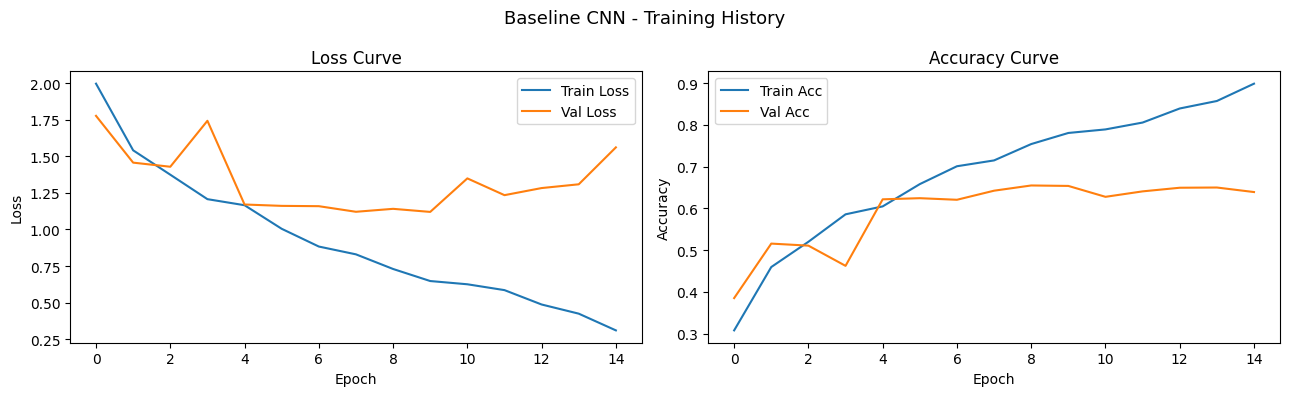

In [22]:
def plot_history(history, title="Training History"):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
  fig.suptitle(title, fontsize=13)

  ax1.plot(history["train_loss"], label="Train Loss")
  ax1.plot(history["val_loss"],   label="Val Loss")
  ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
  ax1.set_title("Loss Curve"); ax1.legend()

  ax2.plot(history["train_acc"], label="Train Acc")
  ax2.plot(history["val_acc"],   label="Val Acc")
  ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
  ax2.set_title("Accuracy Curve"); ax2.legend()

  plt.tight_layout()
  plt.show()

plot_history(baseline_history, title="Baseline CNN - Training History")

**Model Evaluation**

In [23]:
def full_evaluation(model, loader, device, class_names):
  model.eval()
  all_preds, all_labels = [], []
  with torch.no_grad():
    for imgs, lbls in loader:
      imgs = imgs.to(device)
      preds = model(imgs).argmax(1).cpu()
      all_preds.extend(preds.tolist())
      all_labels.extend(lbls.tolist())
  print(classification_report(all_labels, all_preds, target_names=class_names))
  return all_labels, all_preds

baseline_labels, baseline_preds = full_evaluation(baseline_model, test_loader, device, class_names)

              precision    recall  f1-score   support

     battery       0.59      0.67      0.63       113
  biological       0.63      0.76      0.69       105
   cardboard       0.65      0.77      0.71       211
     clothes       0.83      0.75      0.79       284
       glass       0.65      0.72      0.68       261
       metal       0.53      0.47      0.50       140
       paper       0.53      0.67      0.59       200
     plastic       0.63      0.57      0.60       240
       shoes       0.82      0.55      0.66       217
       trash       0.67      0.49      0.56        68

    accuracy                           0.66      1839
   macro avg       0.66      0.64      0.64      1839
weighted avg       0.67      0.66      0.66      1839



**Confusion Matrix**

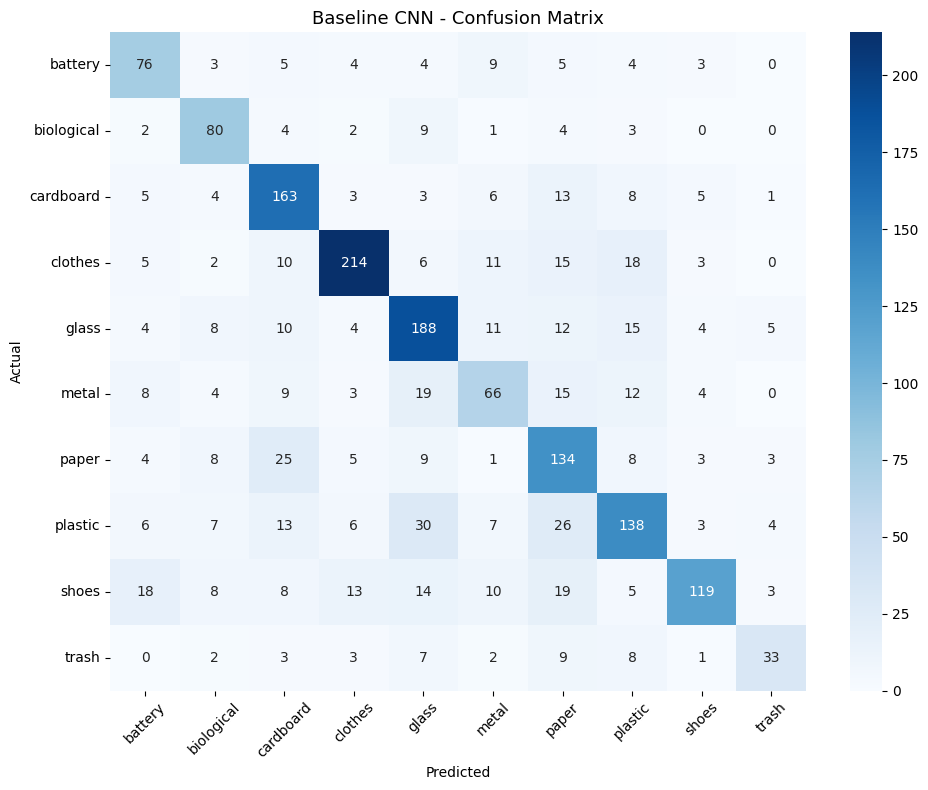

In [24]:
plot_confusion_matrix(baseline_labels, baseline_preds, class_names, title="Baseline CNN - Confusion Matrix")

**Inference on Sample Images**

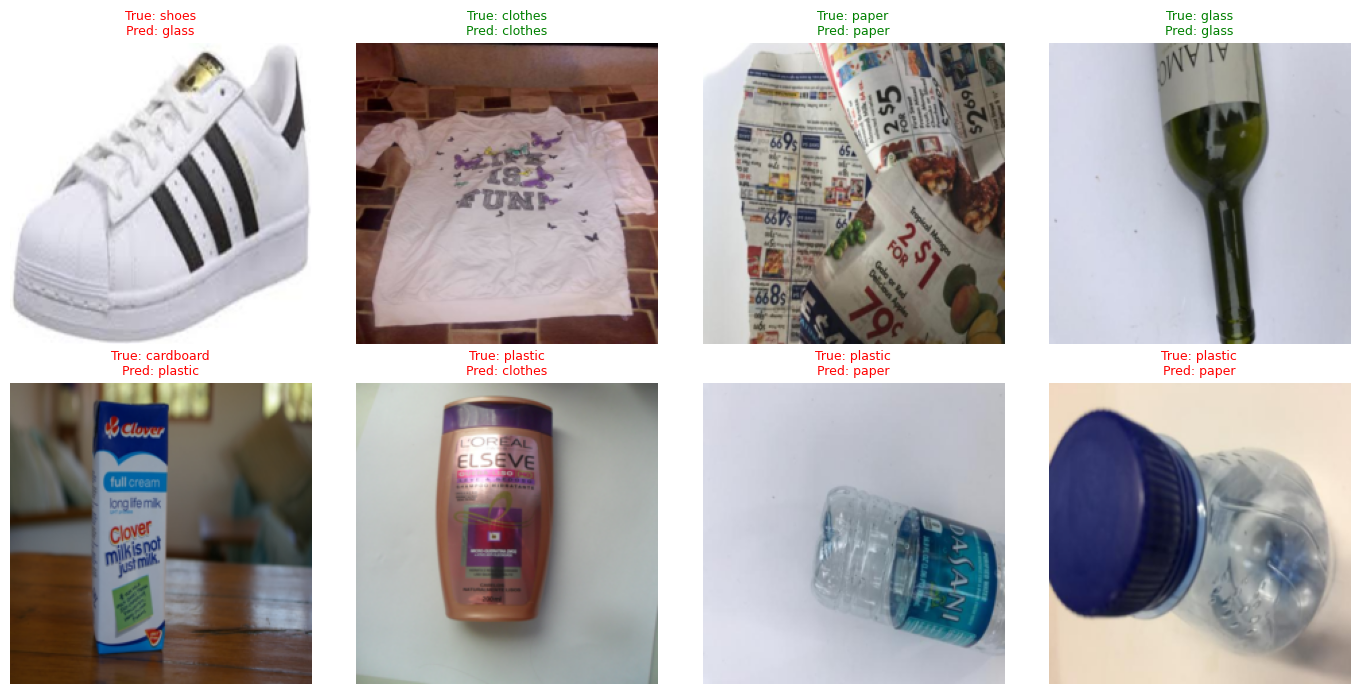

In [25]:
# Pick a few random images from the test set and visualize predictions
def show_predictions(model, dataset, class_names, device, n=8):
  model.eval()
  idxs = random.sample(range(len(dataset)), n)

  fig, axes = plt.subplots(2, 4, figsize=(14, 7))
  axes = axes.flatten()

  # Stats for denormalization for display
  mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
  std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

  with torch.no_grad():
    for ax, idx in zip(axes, idxs):
      img, true_lbl = dataset[idx]
      # forward pass on a single image
      pred = model(img.unsqueeze(0).to(device)).argmax(1).item()

      # denormalize for display
      disp = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
      ax.imshow(disp)
      ax.axis("off")
      color = "green" if pred == true_lbl else "red"
      ax.set_title(f"True: {class_names[true_lbl]}\nPred: {class_names[pred]}", color=color, fontsize=9)

  plt.tight_layout()
  plt.show()

show_predictions(baseline_model, test_ds, class_names, device, n=8)

### Deeper Architecture with Regularization Layer

**Model Architecture**

In [26]:
# Deeper CNN: roughly doubled the conv layers, and added BatchNorm + Dropout + Early Stopping for regularization
class DeeperCNN(nn.Module):
  def __init__(self, num_classes=10, dropout=0.1, use_bn=True):
    super().__init__()
    self.use_bn = use_bn

    # Block 1
    self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(32)

    # Block 2
    self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)

    # Block 3
    self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    self.pool = nn.MaxPool2d(2, 2)
    self.dropout = nn.Dropout(dropout)

    # FCN head
    self.fc1 = nn.Linear(128 * 28 * 28, 512)
    self.fc2 = nn.Linear(512, 128)
    self.fc3 = nn.Linear(128, num_classes)

  def _bn(self, x, layer):
    # apply batchnorm only if enabled (helps for ablation)
    return layer(x) if self.use_bn else x

  def forward(self, x):
    # Block 1
    x = F.relu(self.conv1a(x))
    x = F.relu(self._bn(self.conv1b(x), self.bn1))
    x = self.pool(x)

    # Block 2
    x = F.relu(self.conv2a(x))
    x = F.relu(self._bn(self.conv2b(x), self.bn2))
    x = self.pool(x)

    # Block 3
    x = F.relu(self.conv3a(x))
    x = F.relu(self._bn(self.conv3b(x), self.bn3))
    x = self.pool(x)

    # Flatten + dense head
    x = x.view(x.size(0), -1)
    x = self.dropout(F.relu(self.fc1(x)))
    x = self.dropout(F.relu(self.fc2(x)))
    return self.fc3(x)

deeper_model = DeeperCNN(num_classes=num_classes).to(device)
print(deeper_model)

DeeperCNN(
  (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=Tr

In [27]:
f"Total parameters: {sum(p.numel() for p in deeper_model.parameters()):,}"

'Total parameters: 51,735,146'

**Model Training**

In [28]:
criterion = nn.CrossEntropyLoss()
deeper_optimizer = torch.optim.Adam(deeper_model.parameters(), lr=1e-3)

deeper_history, deeper_time = train_model(
    deeper_model, train_loader, val_loader,
    criterion, deeper_optimizer, epochs=40, device=device,
    patience=8, save_path="best_deeper.pth"
)

Epoch 01/40 train_loss: 2.8702 train_acc: 0.1876 val_loss: 2.0590 val_acc: 0.2360
Epoch 02/40 train_loss: 2.0143 train_acc: 0.2556 val_loss: 1.8855 val_acc: 0.3295
Epoch 03/40 train_loss: 1.8250 train_acc: 0.3505 val_loss: 1.6816 val_acc: 0.4024
Epoch 04/40 train_loss: 1.6634 train_acc: 0.4167 val_loss: 1.5720 val_acc: 0.4595
Epoch 05/40 train_loss: 1.5884 train_acc: 0.4439 val_loss: 1.4993 val_acc: 0.4834
Epoch 06/40 train_loss: 1.5518 train_acc: 0.4629 val_loss: 1.5895 val_acc: 0.4600
Epoch 07/40 train_loss: 1.4743 train_acc: 0.4950 val_loss: 1.5020 val_acc: 0.4780
Epoch 08/40 train_loss: 1.5121 train_acc: 0.4717 val_loss: 1.4923 val_acc: 0.4878
Epoch 09/40 train_loss: 1.4563 train_acc: 0.5004 val_loss: 1.4067 val_acc: 0.5204
Epoch 10/40 train_loss: 1.3558 train_acc: 0.5335 val_loss: 1.4800 val_acc: 0.4997
Epoch 11/40 train_loss: 1.3497 train_acc: 0.5358 val_loss: 1.3666 val_acc: 0.5487
Epoch 12/40 train_loss: 1.3023 train_acc: 0.5503 val_loss: 1.3739 val_acc: 0.5623
Epoch 13/40 trai

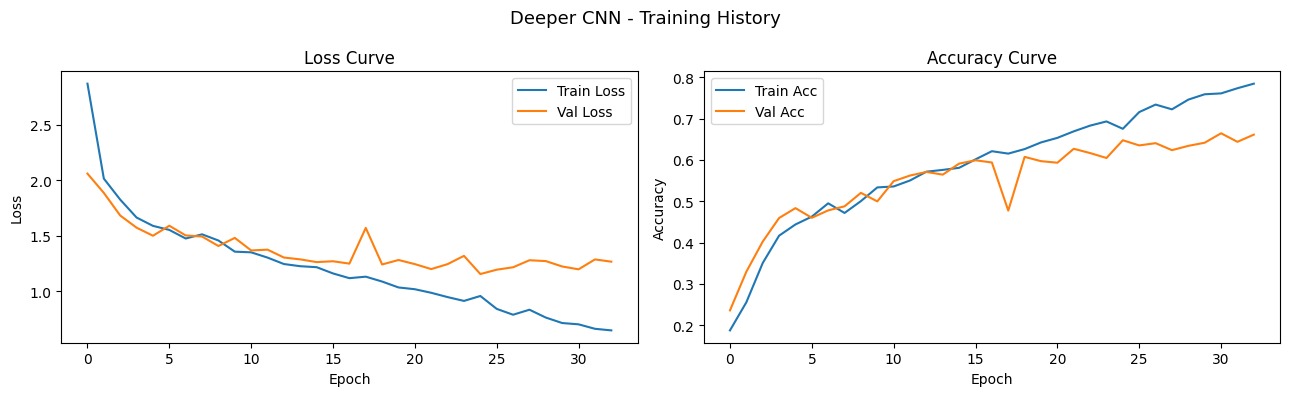

In [29]:
plot_history(deeper_history, title="Deeper CNN - Training History")

**Model Evaluation**

In [30]:
deeper_labels, deeper_preds = full_evaluation(deeper_model, test_loader, device, class_names)

              precision    recall  f1-score   support

     battery       0.76      0.60      0.67       113
  biological       0.53      0.66      0.58       105
   cardboard       0.74      0.71      0.73       211
     clothes       0.79      0.79      0.79       284
       glass       0.58      0.71      0.64       261
       metal       0.41      0.39      0.40       140
       paper       0.54      0.49      0.51       200
     plastic       0.67      0.60      0.64       240
       shoes       0.64      0.69      0.66       217
       trash       0.53      0.38      0.44        68

    accuracy                           0.64      1839
   macro avg       0.62      0.60      0.61      1839
weighted avg       0.64      0.64      0.63      1839



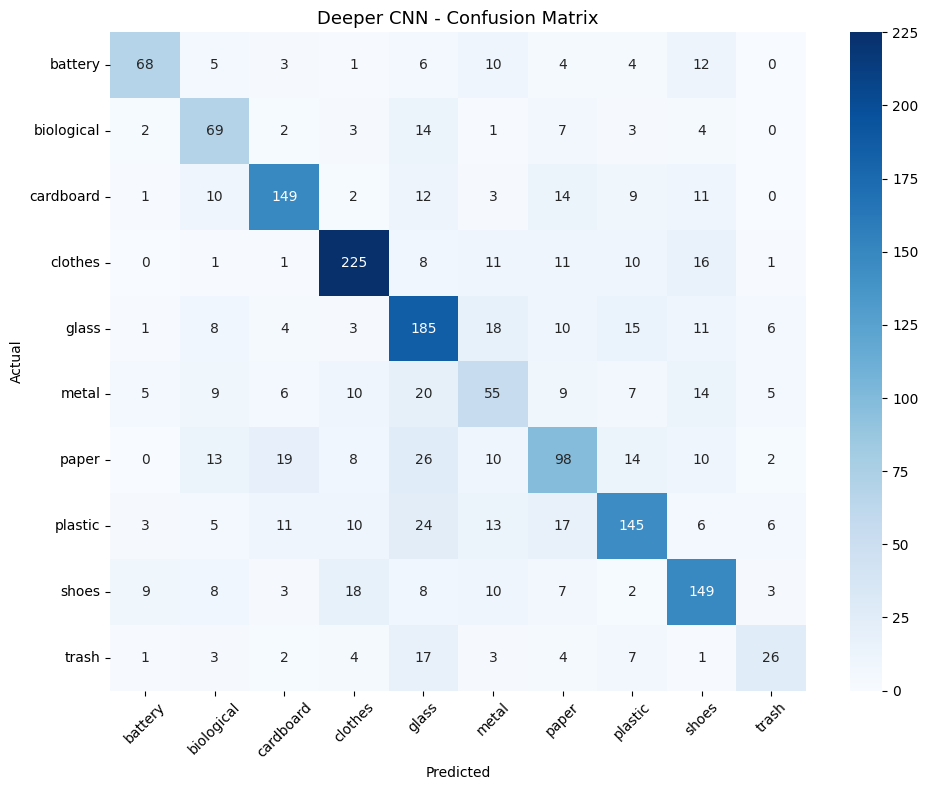

In [31]:
plot_confusion_matrix(deeper_labels, deeper_preds, class_names, title="Deeper CNN - Confusion Matrix")

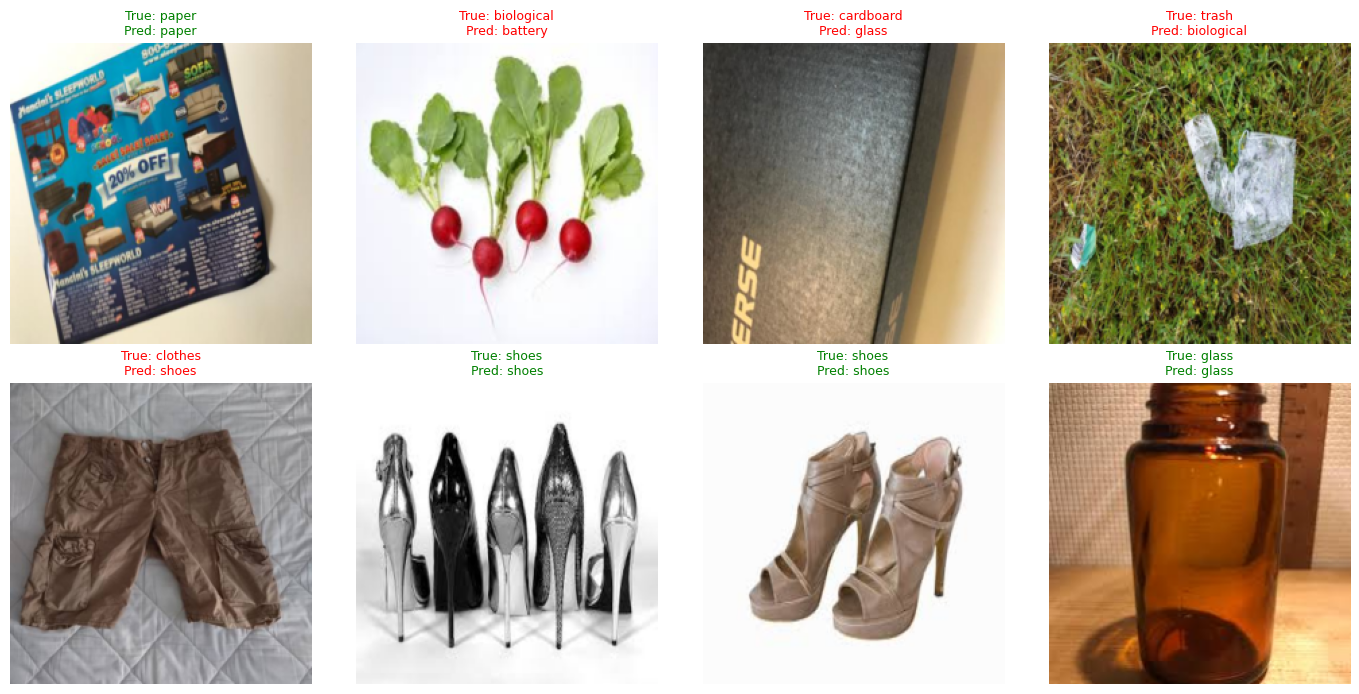

In [32]:
show_predictions(deeper_model, test_ds, class_names, device, n=8)

### Experimentation and Comparative Analysis

**Baseline vs. Deeper Model Performance**

In [33]:
# Compare final test accuracy and val curves between the two models
baseline_acc = accuracy_score(baseline_labels, baseline_preds)
deeper_acc = accuracy_score(deeper_labels, deeper_preds)

print(f"Baseline test accuracy: {baseline_acc:.4f}")
print(f"Deeper test accuracy: {deeper_acc:.4f}")

Baseline test accuracy: 0.6585
Deeper test accuracy: 0.6357


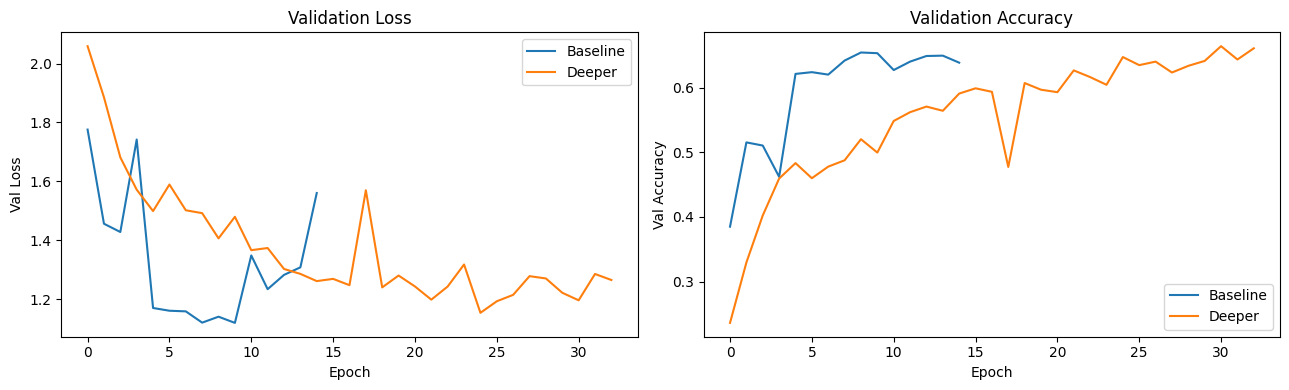

In [34]:
# Plot val accuracy/loss of both on the same axes for direct comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(baseline_history["val_loss"], label="Baseline")
ax1.plot(deeper_history["val_loss"], label="Deeper")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Val Loss"); ax1.set_title("Validation Loss"); ax1.legend()

ax2.plot(baseline_history["val_acc"], label="Baseline")
ax2.plot(deeper_history["val_acc"], label="Deeper")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Accuracy"); ax2.set_title("Validation Accuracy"); ax2.legend()

plt.tight_layout()
plt.show()

**Computational Efficiency**

In [35]:
# Compare training time and parameter count
baseline_params = sum(p.numel() for p in baseline_model.parameters())
deeper_params = sum(p.numel() for p in deeper_model.parameters())

print(f"Baseline params: {baseline_params:,}, training time: {baseline_time:.1f}s")
print(f"Deeper params: {deeper_params:,}, training time: {deeper_time:.1f}s")

Baseline params: 51,540,938, training time: 959.4s
Deeper params: 51,735,146, training time: 2430.9s


**Optimizer Analysis: SGD vs Adam**

In [36]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Train a fresh deeper model with SGD for fair comparison against the Adam run above
deeper_sgd = DeeperCNN(num_classes=num_classes).to(device)
sgd_optimizer = torch.optim.SGD(deeper_sgd.parameters(), lr=1e-2, momentum=0.9)

sgd_history, sgd_time = train_model(
    deeper_sgd, train_loader, val_loader,
    criterion, sgd_optimizer, epochs=40, device=device,
    patience=8
)

Epoch 01/40 train_loss: 1.7837 train_acc: 0.3617 val_loss: 1.6622 val_acc: 0.4279
Epoch 02/40 train_loss: 1.5523 train_acc: 0.4583 val_loss: 1.5412 val_acc: 0.4709
Epoch 03/40 train_loss: 1.3832 train_acc: 0.5217 val_loss: 1.7415 val_acc: 0.4138
Epoch 04/40 train_loss: 1.3591 train_acc: 0.5336 val_loss: 1.2832 val_acc: 0.5791
Epoch 05/40 train_loss: 1.2666 train_acc: 0.5671 val_loss: 1.4688 val_acc: 0.5209
Epoch 06/40 train_loss: 1.2550 train_acc: 0.5730 val_loss: 1.3128 val_acc: 0.5525
Epoch 07/40 train_loss: 1.1236 train_acc: 0.6181 val_loss: 1.2990 val_acc: 0.5769
Epoch 08/40 train_loss: 1.0431 train_acc: 0.6479 val_loss: 1.2288 val_acc: 0.5824
Epoch 09/40 train_loss: 1.0055 train_acc: 0.6568 val_loss: 1.3158 val_acc: 0.6041
Epoch 10/40 train_loss: 1.0205 train_acc: 0.6528 val_loss: 1.2463 val_acc: 0.6036
Epoch 11/40 train_loss: 0.9242 train_acc: 0.6913 val_loss: 1.2442 val_acc: 0.5824
Epoch 12/40 train_loss: 0.8939 train_acc: 0.6927 val_loss: 1.1955 val_acc: 0.6417
Epoch 13/40 trai

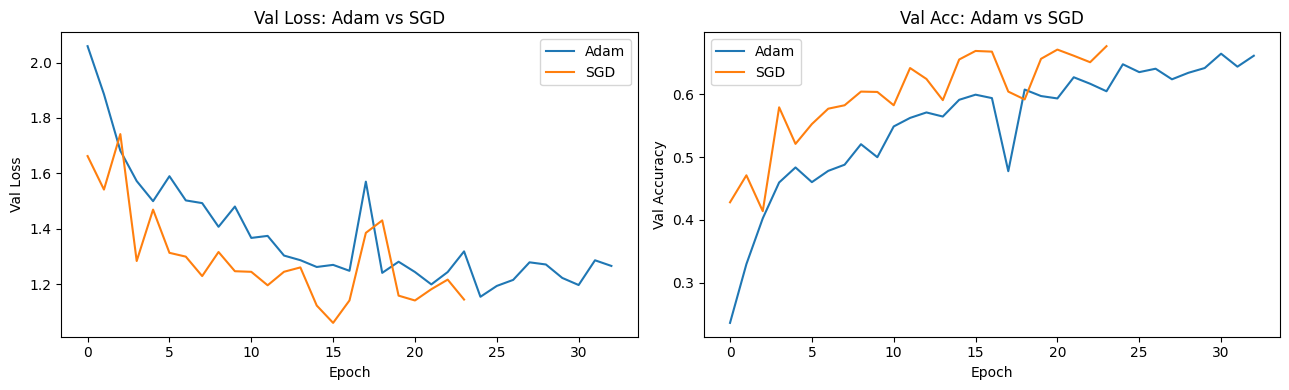

In [37]:
# Compare convergence behaviour of the two optimizers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(deeper_history["val_loss"], label="Adam")
ax1.plot(sgd_history["val_loss"], label="SGD")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Val Loss"); ax1.set_title("Val Loss: Adam vs SGD"); ax1.legend()

ax2.plot(deeper_history["val_acc"], label="Adam")
ax2.plot(sgd_history["val_acc"], label="SGD")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Accuracy"); ax2.set_title("Val Acc: Adam vs SGD"); ax2.legend()

plt.tight_layout()
plt.show()

In [38]:
sgd_labels, sgd_preds = full_evaluation(deeper_sgd, test_loader, device, class_names)
print(f"Deeper + Adam test accuracy: {deeper_acc:.4f}")
print(f"Deeper + SGD  test accuracy: {accuracy_score(sgd_labels, sgd_preds):.4f}")

              precision    recall  f1-score   support

     battery       0.74      0.66      0.70       113
  biological       0.67      0.72      0.69       105
   cardboard       0.82      0.71      0.76       211
     clothes       0.84      0.78      0.81       284
       glass       0.71      0.70      0.71       261
       metal       0.52      0.49      0.51       140
       paper       0.59      0.56      0.57       200
     plastic       0.55      0.68      0.61       240
       shoes       0.68      0.71      0.70       217
       trash       0.49      0.59      0.53        68

    accuracy                           0.67      1839
   macro avg       0.66      0.66      0.66      1839
weighted avg       0.68      0.67      0.68      1839

Deeper + Adam test accuracy: 0.6357
Deeper + SGD  test accuracy: 0.6748


**Ablation Study**

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Remove BatchNorm to see how much it actually contributes
ablation_model = DeeperCNN(num_classes=num_classes, use_bn=False).to(device)
ablation_optimizer = torch.optim.Adam(ablation_model.parameters(), lr=1e-3)

ablation_history, ablation_time = train_model(
    ablation_model, train_loader, val_loader,
    criterion, ablation_optimizer, epochs=40, device=device, patience=8
)

Epoch 01/40 train_loss: 2.0572 train_acc: 0.2478 val_loss: 1.9216 val_acc: 0.3018
Epoch 02/40 train_loss: 1.7272 train_acc: 0.3754 val_loss: 1.5928 val_acc: 0.4470
Epoch 03/40 train_loss: 1.5518 train_acc: 0.4502 val_loss: 1.5516 val_acc: 0.4671
Epoch 04/40 train_loss: 1.4525 train_acc: 0.4923 val_loss: 1.4036 val_acc: 0.5198
Epoch 05/40 train_loss: 1.3447 train_acc: 0.5370 val_loss: 1.4233 val_acc: 0.5356
Epoch 06/40 train_loss: 1.2775 train_acc: 0.5642 val_loss: 1.2463 val_acc: 0.5840
Epoch 07/40 train_loss: 1.1513 train_acc: 0.6084 val_loss: 1.3301 val_acc: 0.5617
Epoch 08/40 train_loss: 1.0621 train_acc: 0.6406 val_loss: 1.2061 val_acc: 0.6226
Epoch 09/40 train_loss: 0.9883 train_acc: 0.6636 val_loss: 1.1960 val_acc: 0.6248
Epoch 10/40 train_loss: 0.9434 train_acc: 0.6876 val_loss: 1.1806 val_acc: 0.6351
Epoch 11/40 train_loss: 0.7990 train_acc: 0.7307 val_loss: 1.1209 val_acc: 0.6438
Epoch 12/40 train_loss: 0.7336 train_acc: 0.7528 val_loss: 1.1579 val_acc: 0.6504
Epoch 13/40 trai

In [ ]:
ablation_labels, ablation_preds = full_evaluation(ablation_model, test_loader, device, class_names)
ablation_acc = accuracy_score(ablation_labels, ablation_preds)

print(f"Deeper (with BatchNorm) test accuracy: {deeper_acc:.4f}")
print(f"Deeper (without BatchNorm) test accuracy: {ablation_acc:.4f}")

**Challenges and Observations**

In [ ]:
# Summary of all the runs in one place
print(f"{'Model':<35}{'Test Acc':<12}{'Train Time (s)':<15}")
print("-" * 62)
print(f"{'Baseline CNN':<35}{baseline_acc:<12.4f}{baseline_time:<15.1f}")
print(f"{'Deeper CNN (Adam, with BN)':<35}{deeper_acc:<12.4f}{deeper_time:<15.1f}")
print(f"{'Deeper CNN (SGD, with BN)':<35}{accuracy_score(sgd_labels, sgd_preds):<12.4f}{sgd_time:<15.1f}")
print(f"{'Deeper CNN (Adam, no BN)':<35}{ablation_acc:<12.4f}{ablation_time:<15.1f}")

print(f"\nDevice used: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

## Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

### Loading and Adapting a Pre - Trained Model

In [ ]:
from torchvision import models
from torchvision.models import ResNet18_Weights

In [ ]:
# Load ResNet18 with ImageNet pretrained weights
weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)

# Freeze all conv layers first (feature extraction stage)
for param in resnet.parameters():
  param.requires_grad = False

# Replace the final FC layer to match our 10 classes
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)

resnet = resnet.to(device)
print(resnet)

In [ ]:
# Verify only the new fc layer is trainable at this stage
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())
f"Trainable params: {trainable:,} / Total: {total:,}"

### Model Training and Fine - Tuning

**Stage 1: Feature Extraction (frozen backbone)**

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Only the new FC head trains here
fe_optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

fe_history, fe_time = train_model(
    resnet, train_loader, val_loader,
    criterion, fe_optimizer, epochs=6, device=device, patience=6
)

In [ ]:
plot_history(fe_history, title="ResNet18 - Feature Extraction")

### Model Evaluation and Prediction

In [ ]:
resnet_labels, resnet_preds = full_evaluation(resnet, test_loader, device, class_names)
resnet_acc = accuracy_score(resnet_labels, resnet_preds)
f"Transfer learning test accuracy: {resnet_acc:.4f}"

In [ ]:
plot_confusion_matrix(resnet_labels, resnet_preds, class_names, title="ResNet18 - Confusion Matrix")

In [ ]:
show_predictions(resnet, test_ds, class_names, device, n=8)

**Final Comparison: Scratch vs Transfer Learning**

In [ ]:
print(f"{'Model':<35}{'Test Acc':<12}{'Train Time (s)':<15}")
print("-" * 62)
print(f"{'Baseline CNN (scratch)':<35}{baseline_acc:<12.4f}{baseline_time:<15.1f}")
print(f"{'Deeper CNN (scratch)':<35}{deeper_acc:<12.4f}{deeper_time:<15.1f}")
print(f"{'ResNet18 (transfer learning)':<35}{resnet_acc:<12.4f}{fe_time:<15.1f}")